# SAE Analysis (within one cancer)


This notebook analyzes a trained SAE within a single cancer context using **visual-first** diagnostics: PCA/t-SNE projections, feature–score correlations, and feature–feature correlation structure.


Any statistical test included is paired with an explicit interpretation (what it would mean biologically / for the embedding manifold).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import yaml

from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import shortest_path
from scipy.stats import spearmanr

# Make `src/` importable (namespace packages; no __init__.py needed)
REPO_ROOT = Path.cwd().resolve()
SRC_DIR = (REPO_ROOT / "src").resolve()
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from SAE.SAE_training.model import SAEConfig, SparseAutoencoder
from SAE.SAE_training.utils.data import build_artifacts, extract_concat_matrix
from SAE.LLM_pipeline.utils.general import find_pair_index, sample_name
from SAE.manifold.utils.projection import projection_state

sns.set_theme(style="whitegrid")
print("Repo root:", REPO_ROOT)

Repo root: /home/guoyu/SLformer_interpretation


In [2]:
# --- Load config + resolve run directory ---
CONFIG_PATH = (REPO_ROOT / "src" / "SAE" / "SAE_training" / "config" / "train_config.yaml").resolve()
MANIFOLD_CONFIG_PATH = (REPO_ROOT / "src" / "SAE" / "manifold" / "config" / "manifold_config.yaml").resolve()

cfg = yaml.safe_load(CONFIG_PATH.read_text(encoding="utf-8"))
manifold_cfg = yaml.safe_load(MANIFOLD_CONFIG_PATH.read_text(encoding="utf-8"))
analysis_cfg = manifold_cfg["analysis"]
projection_cfg = manifold_cfg["projection"]

paths_cfg = cfg["paths"]
scope_cfg = cfg["scope"]

model_dict = dict(cfg["model"])
model_dict["d_hidden"] = int(model_dict["d_hidden"])
model_cfg = SAEConfig(**model_dict)

CANCER = str(scope_cfg["cancer"])
SCORE_COL = str(scope_cfg["score_col"])
SEED = int(scope_cfg["seed"])

embeddings_pkl = Path(paths_cfg["embeddings_pkl"]).expanduser().resolve()
prediction_csvs = [Path(p).expanduser().resolve() for p in paths_cfg["prediction_csvs"]]
output_base_dir = Path(paths_cfg["output_base_dir"]).expanduser().resolve()
slformer_output_subdir = str(paths_cfg["slformer_output_subdir"])

run_name = f"hidden{model_cfg.d_hidden}_gate{model_cfg.gate_weight}_orth{model_cfg.orth_weight}_k{model_cfg.topk}"
run_dir = output_base_dir / slformer_output_subdir / CANCER / run_name
print("Run dir:", run_dir)

# Load normalization and SAE weights
mu = np.load(run_dir / "norm" / "mu.npy")
sigma = np.load(run_dir / "norm" / "sigma.npy")

ckpt = torch.load(run_dir / "final.pt", map_location="cpu")
sae_cfg_loaded = SAEConfig(**ckpt["sae_cfg"])
model = SparseAutoencoder(sae_cfg_loaded)
model.load_state_dict(ckpt["state_dict"])
model.eval()
print("Loaded SAE:", sae_cfg_loaded)
print("Analysis config:", analysis_cfg)

Run dir: /home/guoyu/SLformer_interpretation/output/SAE/slformer/mix/hidden4096_gate0.5_orth1_k64
Loaded SAE: SAEConfig(d_in=1024, d_hidden=4096, activation='jumprelu', orth_weight=1, decoder_unit_norm=True, topk=64, gate_weight=0.5, jump_threshold=0.0)
Analysis config: {'subsample_max': 1200, 'knn_k': 30, 'geo_k': 25, 'ridge_alpha': 0.001}


In [3]:
# --- Load within-cancer dataset ---
artifacts = build_artifacts(embeddings_pkl=embeddings_pkl, prediction_csvs=prediction_csvs)
X, y, meta = extract_concat_matrix(artifacts, cancer=CANCER, seed=SEED, use_score_col=SCORE_COL)
Xn = ((X - mu) / (sigma + 1e-8)).astype(np.float32)
print("X:", Xn.shape, "y:", y.shape)
meta.head()

X: (58672, 1024) y: (58672,)


,primary_gene,partner_gene,cancer,score,fold
0,AKT1,BCL2,KIRC,0.000425,0
1,PTEN,RUNX1,KIRC,0.001516,0
2,HDAC6,SMARCA4,KIRC,0.005020,0
3,ARID1A,PIK3R1,KIRC,0.000929,0
4,BRCA1,HDAC1,KIRC,0.015028,0


In [4]:
# --- Compute SAE codes Z ---
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

bs = 2048
Z_parts = []
with torch.no_grad():
    for i in range(0, Xn.shape[0], bs):
        xb = torch.from_numpy(Xn[i:i+bs]).to(device)
        zb = model.encode(xb).detach().cpu().numpy()
        Z_parts.append(zb)
Z = np.concatenate(Z_parts, axis=0)
print("Z:", Z.shape)

Z: (58672, 4096)


In [5]:
# # --- Visualization 1: local point PCA check (manifold locality in X and Z) ---
# # Goal: test whether neighborhoods are low-dimensional locally, not globally.
from tqdm import tqdm

sub_n = int(analysis_cfg["subsample_max"])

rng = np.random.default_rng(SEED)
sub_idx = rng.choice(Z.shape[0], size=sub_n, replace=False)

X_sub = Xn[sub_idx]
Z_sub = Z[sub_idx]
y_sub = y[sub_idx]

k_local = int(analysis_cfg["knn_k"])

var_target = 0.90

nbrs_x = NearestNeighbors(n_neighbors=k_local + 1, metric="euclidean").fit(X_sub)
idx_x = nbrs_x.kneighbors(return_distance=False)

nbrs_z = NearestNeighbors(n_neighbors=k_local + 1, metric="euclidean").fit(Z_sub)
idx_z = nbrs_z.kneighbors(return_distance=False)

## Local Manifold Diagnostics (replace global/correlation tests)

These checks target your actual goal: evaluate whether we captured usable local manifold structure instead of relying on global PCA/correlation bars.

1. Local point PCA check: neighborhood-wise intrinsic dimension in X and Z.
2. Local linear fit: can score be approximated by a linear model in local tangent coordinates?
3. Geodesic consistency: are graph geodesic distances preserved from X-space to Z-space?

  0%|          | 0/1200 [00:00<?, ?it/s]

  0%|          | 4/1200 [00:00<00:52, 22.75it/s]

  1%|          | 7/1200 [00:00<00:48, 24.85it/s]

  1%|          | 14/1200 [00:00<00:29, 40.87it/s]

  2%|▏         | 21/1200 [00:00<00:23, 50.08it/s]

...

 99%|█████████▉| 1187/1200 [00:30<00:00, 60.60it/s]

100%|█████████▉| 1194/1200 [00:31<00:00, 22.86it/s]

100%|█████████▉| 1199/1200 [00:31<00:00, 19.43it/s]

100%|██████████| 1200/1200 [00:31<00:00, 37.67it/s]

Local linear fit R^2 summary
  X-space median=0.968, mean=0.946
  Z-space median=0.971, mean=0.952


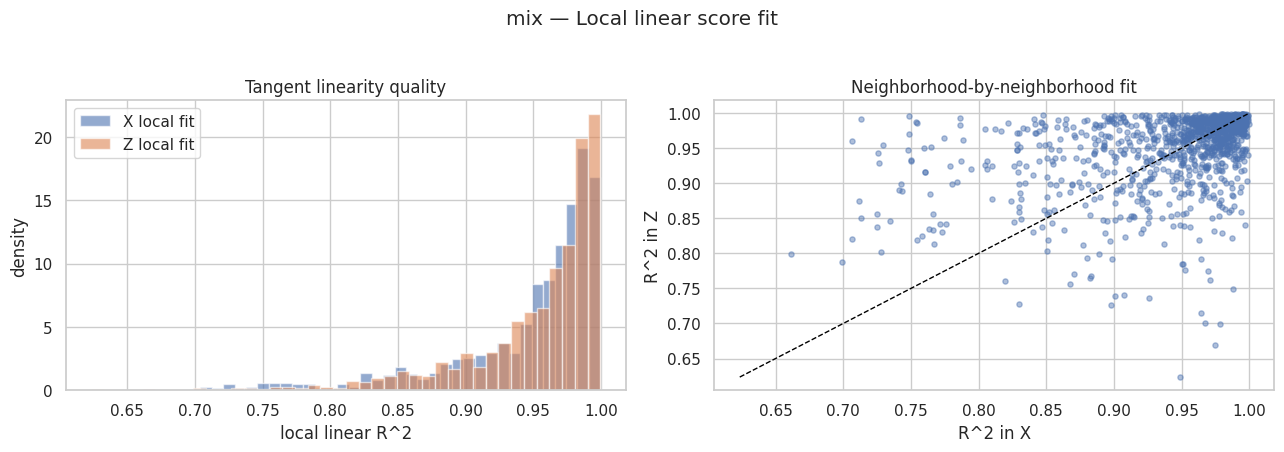

In [ ]:
# --- Visualization 2: local linear fit in tangent coordinates ---
# Fit local linear score models in each neighborhood and compare fit quality in X vs Z.

ridge = float(analysis_cfg["ridge_alpha"])
tangent_dim = int(projection_cfg["tangent_dim"])
r2_x = []
r2_z = []

for i in tqdm(range(sub_n), desc="Local linear fits"):
    nxi = idx_x[i, 1:]
    nzi = idx_z[i, 1:]

    # Local tangent coords from local PCA in X
    X_loc = X_sub[nxi]
    y_loc = y_sub[nxi]
    X_centered = X_loc - X_loc.mean(axis=0, keepdims=True)
    pca_x = PCA(n_components=tangent_dim, random_state=SEED)
    Ux = pca_x.fit_transform(X_centered)

    # Local tangent coords from local PCA in Z
    Z_loc = Z_sub[nzi]
    yz_loc = y_sub[nzi]
    Z_centered = Z_loc - Z_loc.mean(axis=0, keepdims=True)
    pca_z = PCA(n_components=tangent_dim, random_state=SEED)
    Uz = pca_z.fit_transform(Z_centered)

    def fit_r2(U: np.ndarray, yv: np.ndarray, alpha: float) -> float:
        yv = yv.astype(np.float64)
        U = U.astype(np.float64)
        Xd = np.concatenate([np.ones((U.shape[0], 1)), U], axis=1)
        I = np.eye(Xd.shape[1], dtype=np.float64)
        I[0, 0] = 0.0  # do not regularize intercept
        beta = np.linalg.solve(Xd.T @ Xd + alpha * I, Xd.T @ yv)
        yhat = Xd @ beta
        ss_res = float(np.sum((yv - yhat) ** 2))
        ss_tot = float(np.sum((yv - yv.mean()) ** 2) + 1e-12)
        return 1.0 - ss_res / ss_tot

    r2_x.append(fit_r2(Ux, y_loc, ridge))
    r2_z.append(fit_r2(Uz, yz_loc, ridge))

r2_x = np.asarray(r2_x)
r2_z = np.asarray(r2_z)
print("Local linear fit R^2 summary")
print(f"  X-space median={np.median(r2_x):.3f}, mean={np.mean(r2_x):.3f}")
print(f"  Z-space median={np.median(r2_z):.3f}, mean={np.mean(r2_z):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
ax0, ax1 = axes

ax0.hist(r2_x, bins=40, alpha=0.6, density=True, label="X local fit")
ax0.hist(r2_z, bins=40, alpha=0.6, density=True, label="Z local fit")
ax0.set_xlabel("local linear R^2")
ax0.set_ylabel("density")
ax0.set_title("Tangent linearity quality")
ax0.legend()

ax1.scatter(r2_x, r2_z, s=14, alpha=0.45)
mn = float(min(r2_x.min(), r2_z.min()))
mx = float(max(r2_x.max(), r2_z.max()))
ax1.plot([mn, mx], [mn, mx], linestyle="--", color="black", linewidth=1)
ax1.set_xlabel("R^2 in X")
ax1.set_ylabel("R^2 in Z")
ax1.set_title("Neighborhood-by-neighborhood fit")

fig.suptitle(f"{CANCER} — Local linear score fit")
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

Geodesic consistency (Spearman rho): 0.8216 (p=0.000e+00)
=== Manifold Quality Summary ===
local linear R^2 median (X): 0.968
local linear R^2 median (Z): 0.971
geodesic consistency Spearman rho: 0.8216


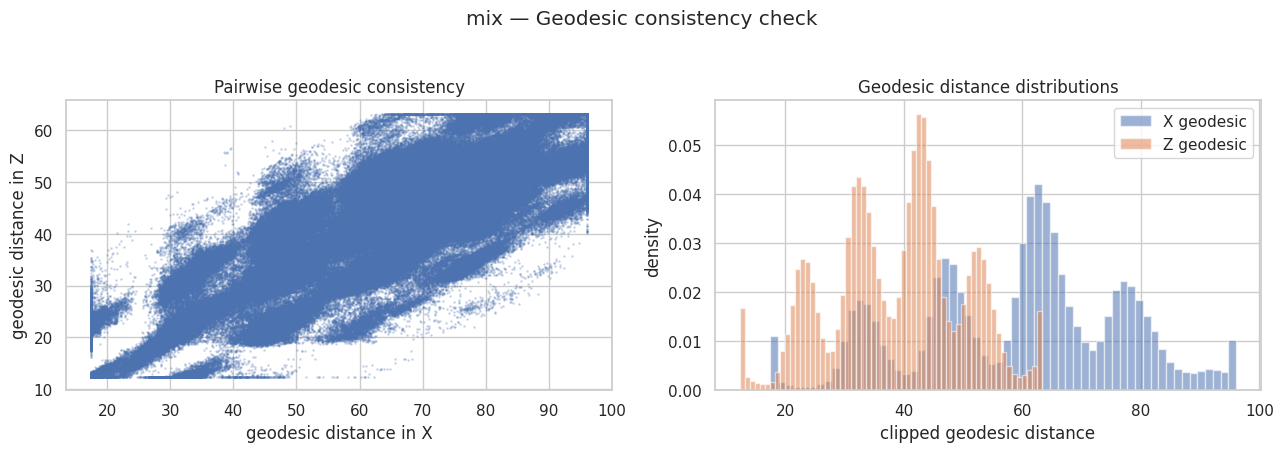

In [7]:
# --- Visualization 3: geodesic consistency check (kNN graph distances) ---
# Compare graph geodesic distances in X-space vs Z-space on the same sample subset.

def knn_graph_dist(A: np.ndarray, k: int) -> np.ndarray:
    nbrs = NearestNeighbors(n_neighbors=k + 1, metric="euclidean").fit(A)
    dist, ind = nbrs.kneighbors(A, return_distance=True)
    n = A.shape[0]
    rows = np.repeat(np.arange(n), k)
    cols = ind[:, 1:].reshape(-1)
    vals = dist[:, 1:].reshape(-1)
    G = csr_matrix((vals, (rows, cols)), shape=(n, n))
    # symmetrize graph
    G = 0.5 * (G + G.T)
    D = shortest_path(G, directed=False, unweighted=False)
    return D

geo_k = int(analysis_cfg["geo_k"])
D_x = knn_graph_dist(X_sub, geo_k)
D_z = knn_graph_dist(Z_sub, geo_k)

tri = np.triu_indices(sub_n, k=1)
dx = D_x[tri]
dz = D_z[tri]
finite = np.isfinite(dx) & np.isfinite(dz)
dx = dx[finite]
dz = dz[finite]

rho, pval = spearmanr(dx, dz)
print(f"Geodesic consistency (Spearman rho): {rho:.4f} (p={pval:.3e})")

print("=== Manifold Quality Summary ===")
print(f"local linear R^2 median (X): {float(np.median(r2_x)):.3f}")
print(f"local linear R^2 median (Z): {float(np.median(r2_z)):.3f}")
print(f"geodesic consistency Spearman rho: {float(rho):.4f}")
# Scale for visual comparability
qx = np.quantile(dx, [0.01, 0.99])
qz = np.quantile(dz, [0.01, 0.99])
dx_clip = np.clip(dx, qx[0], qx[1])
dz_clip = np.clip(dz, qz[0], qz[1])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
ax0, ax1 = axes

ax0.scatter(dx_clip, dz_clip, s=1, alpha=0.2)
ax0.set_xlabel("geodesic distance in X")
ax0.set_ylabel("geodesic distance in Z")
ax0.set_title("Pairwise geodesic consistency")

ax1.hist(dx_clip, bins=60, alpha=0.55, density=True, label="X geodesic")
ax1.hist(dz_clip, bins=60, alpha=0.55, density=True, label="Z geodesic")
ax1.set_xlabel("clipped geodesic distance")
ax1.set_ylabel("density")
ax1.set_title("Geodesic distance distributions")
ax1.legend()

fig.suptitle(f"{CANCER} — Geodesic consistency check")
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()